In [1]:
from pathlib import Path
import sys

repo_root = next((parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (parent / 'ndnf_pipeline').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate the repository root')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import datajoint as dj
dj.config.load('/Users/moldor/Documents/KOKI/secrets/dj_local_conf_NDNF_behavior_KOKI.json')#dj_local_conf_NDNF_behavior_KOKI.json #dj_local_conf_NDNF_behavior_HUN cs16-datajoint.koki.local
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
import numpy as np
# connect to the database

/Users/moldor/Documents/KOKI/NDNF-pipeline/.venv/lib/python3.13/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-07-22 09:58:58,421][INFO]: DataJoint is configured from /Users/moldor/Documents/KOKI/secrets/dj_local_conf_NDNF_behavior_KOKI.json
[2026-07-22 09:58:58,495][INFO]: DataJoint 0.14.6 connected to rozmar@datajoint.ndnf.koki.hun-ren.hu:3306


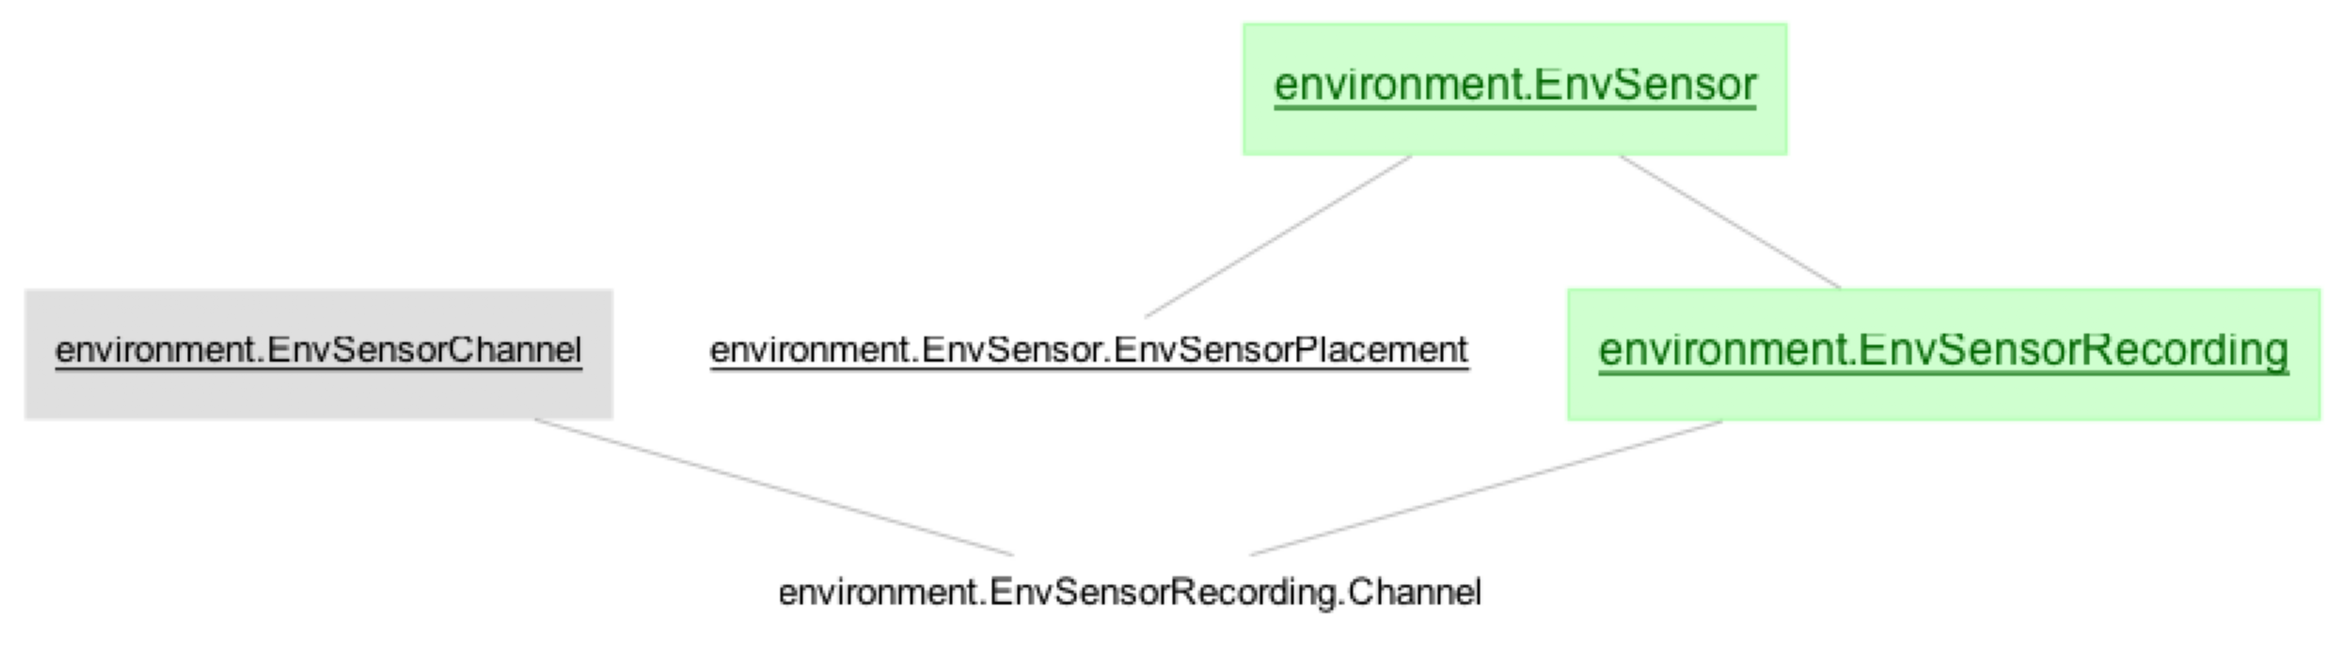

In [3]:
# take a look at the environment schema
from ndnf_pipeline import environment

d = dj.Diagram(environment)
fig = plt.figure(figsize = (30, 30))
d.draw()

In [4]:
environment.EnvSensor.EnvSensorPlacement()

sensor_id e.g. NDNF-#1,placement_date,institute_id,building,room,rig,"location_description ""Marton's desk"", ""top of ventilated box""",placement_comment
NDNF-#1,2026-03-01,KOKI,Tower,213,None,Marton's desk,testing
NDNF-#1,2026-03-18,KOKI,Tower,711,None,Top of ventilated box,testing
NDNF-#1,2026-05-31,KOKI,Tower,704,None,"On the parapet, window side",testing
NDNF-#2,2026-03-01,KOKI,Tower,212,None,on the shelf,testing
NDNF-#2,2026-03-22,KOKI,Tower,711,None,Top of ventilated box,"sensor has problems, not recording, not connecting to the server"
NDNF-#2,2026-03-27,KOKI,Tower,704,None,"On the parapet, window side","testing, sensor put on 5V power source, now it's communicating with the server"
NDNF-#2,2026-05-31,KOKI,Tower,711,None,"Behavior room, next to whiteboard","Final location, testing temperature control and humidity"


In [5]:
subjects = lab.Subject().fetch(format='frame')
subjects.head(100)

,institute_id,user_name,institutional_id,cage_number,date_of_birth,sex
subject_id,,,,,,
BCI81,AI,rozmar,708792,None,2024-01-01,F
human1,KOKI,ridas,human1,None,2010-01-01,M
human_10,KOKI,ridas,human_10,None,2010-01-01,M
human_11,KOKI,ridas,human_11,None,2010-01-02,M
human_12,KOKI,ridas,human_12,None,2010-01-03,M
human_2,KOKI,ridas,human_2,None,2010-01-01,M
human_3,KOKI,ridas,human_3,None,2010-01-01,M
human_4,KOKI,ridas,human_4,None,2010-01-01,M
human_5,KOKI,ridas,human_5,None,2010-01-01,M


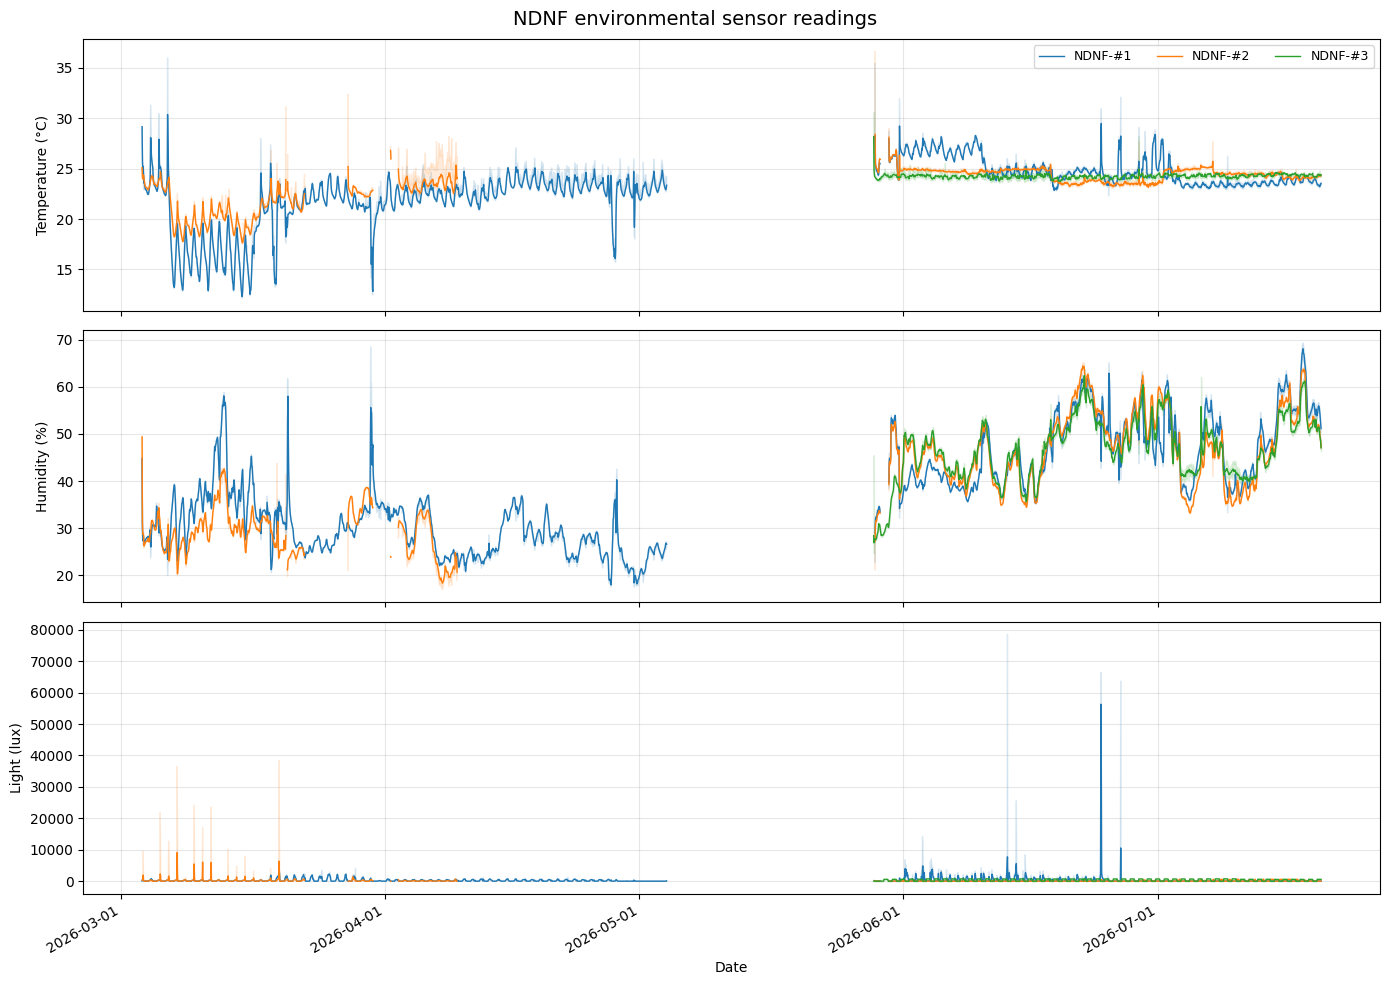

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from ndnf_pipeline import environment

channels_of_interest = ['Temperature', 'Humidity', 'Light']
units = {'Temperature': '°C', 'Humidity': '%', 'Light': 'lux'}

df = (environment.EnvSensorRecording.Channel
      & f"channel_name in {tuple(channels_of_interest)}").fetch(format='frame').reset_index()
df['recording_datetime'] = pd.to_datetime(df['recording_datetime'])
df = df.sort_values('recording_datetime')

sensors = sorted(df['sensor_id'].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(channels_of_interest), 1, figsize=(14, 10), sharex=True)

for ax, channel in zip(axes, channels_of_interest):
    sub = df[df['channel_name'] == channel]
    for i, sensor_id in enumerate(sensors[:]):
        s = sub[sub['sensor_id'] == sensor_id].set_index('recording_datetime').sort_index()
        if s.empty:
            continue
        full_range = pd.date_range(s.index.min(), s.index.max(), freq='h')
        s = s.reindex(full_range)  # missing hours become NaN -> gaps in the line
        color = colors[i % len(colors)]
        ax.plot(s.index, s['value_avg'], label=sensor_id, color=color, linewidth=1)
        ax.fill_between(s.index, s['value_min'], s['value_max'], color=color, alpha=0.15)
    ax.set_ylabel(f"{channel} ({units[channel]})")
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper right', ncol=len(sensors), fontsize=9)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle('NDNF environmental sensor readings', fontsize=14)
plt.tight_layout()
plt.show()

# sensor 1 has data between 03.28-05.04   --  but no mouse weight data yet
# all 3 sensors have data from 05.28
# 711 is the animal room

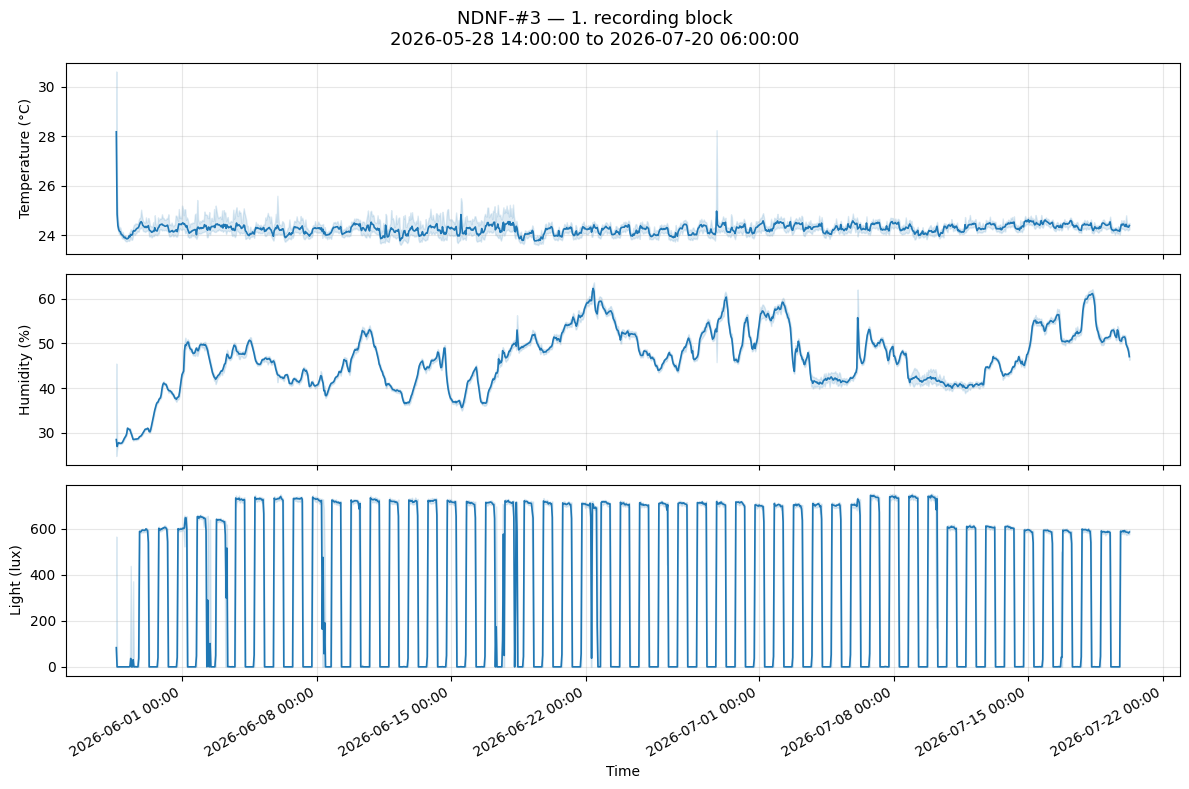

In [7]:
# At this point the sensor is chosen manually. Replacing sensors is not yet handled.

sensor_id = 'NDNF-#3'
group_id = 0
channels_of_interest = ['Temperature', 'Humidity', 'Light']
units = {'Temperature': '°C', 'Humidity': '%', 'Light': 'lux'}

# find the first consecutive recording block for this sensor
times = (environment.EnvSensorRecording & {'sensor_id': sensor_id}).fetch('recording_datetime')
times = pd.to_datetime(pd.Series(times)).sort_values().reset_index(drop=True)
gap_threshold = pd.Timedelta(hours=1.5)
group_ids = (times.diff() > gap_threshold).cumsum()
first_run = times[group_ids == group_id]
start, end = first_run.min(), first_run.max()

# fetch the 3 channels for this sensor, restricted to that period
df = ((environment.EnvSensorRecording.Channel & {'sensor_id': sensor_id})
      & f"channel_name in {tuple(channels_of_interest)}"
      & f"recording_datetime between '{start}' and '{end}'"
      ).fetch(format='frame').reset_index()
df['recording_datetime'] = pd.to_datetime(df['recording_datetime'])
df = df.sort_values('recording_datetime')

fig, axes = plt.subplots(len(channels_of_interest), 1, figsize=(12, 8), sharex=True)

for ax, channel in zip(axes, channels_of_interest):
    sub = df[df['channel_name'] == channel]
    ax.plot(sub['recording_datetime'], sub['value_avg'], color='tab:blue', linewidth=1.2)
    ax.fill_between(sub['recording_datetime'], sub['value_min'], sub['value_max'], color='tab:blue', alpha=0.15)
    ax.set_ylabel(f"{channel} ({units[channel]})")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'{sensor_id} — {group_id+1}. recording block\n{start} to {end}', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Weight measurements during the chosen period

wr_log = (lab.WaterRestriction.WaterRestrictionLog
          & f"log_datetime between '{start}' and '{end}'").fetch(format='frame').reset_index()
wr_log = wr_log.sort_values(['subject_id', 'log_datetime'])
print(wr_log.shape[0])
wr_log.head(100)

319


,subject_id,water_restriction_id,log_datetime,user_name,weight,weight_after_watering,water_given,water_earned,notes
0,M013,M013,2026-06-11 16:30:00,ridas,29.50,None,0.000,None,First day of water restriction- scruffy coat
1,M013,M013,2026-06-12 15:40:59,rozmar,25.50,None,0.800,None,mouse drinking well
2,M013,M013,2026-06-13 13:55:10,rozmar,24.30,None,0.500,None,
3,M013,M013,2026-06-14 15:16:29,ridas,23.30,None,3.000,None,giving back water for 5 minutes
4,M013,M013,2026-06-15 14:12:44,ridas,23.50,None,2.000,None,weight after water = 25
...,...,...,...,...,...,...,...,...,...
95,M015,M015,2026-07-10 16:12:17,rozmar,27.50,28.50,1.000,None,
96,M015,M015,2026-07-11 19:51:56,tchaves,27.20,28.70,2.000,None,
97,M015,M015,2026-07-13 15:08:02,tchaves,26.40,27.60,1.000,None,
98,M015,M015,2026-07-14 18:21:31,rozmar,26.40,27.30,1.000,None,


Using NDNF-#3, window 2026-05-28 14:00:00 to 2026-07-20 06:00:00


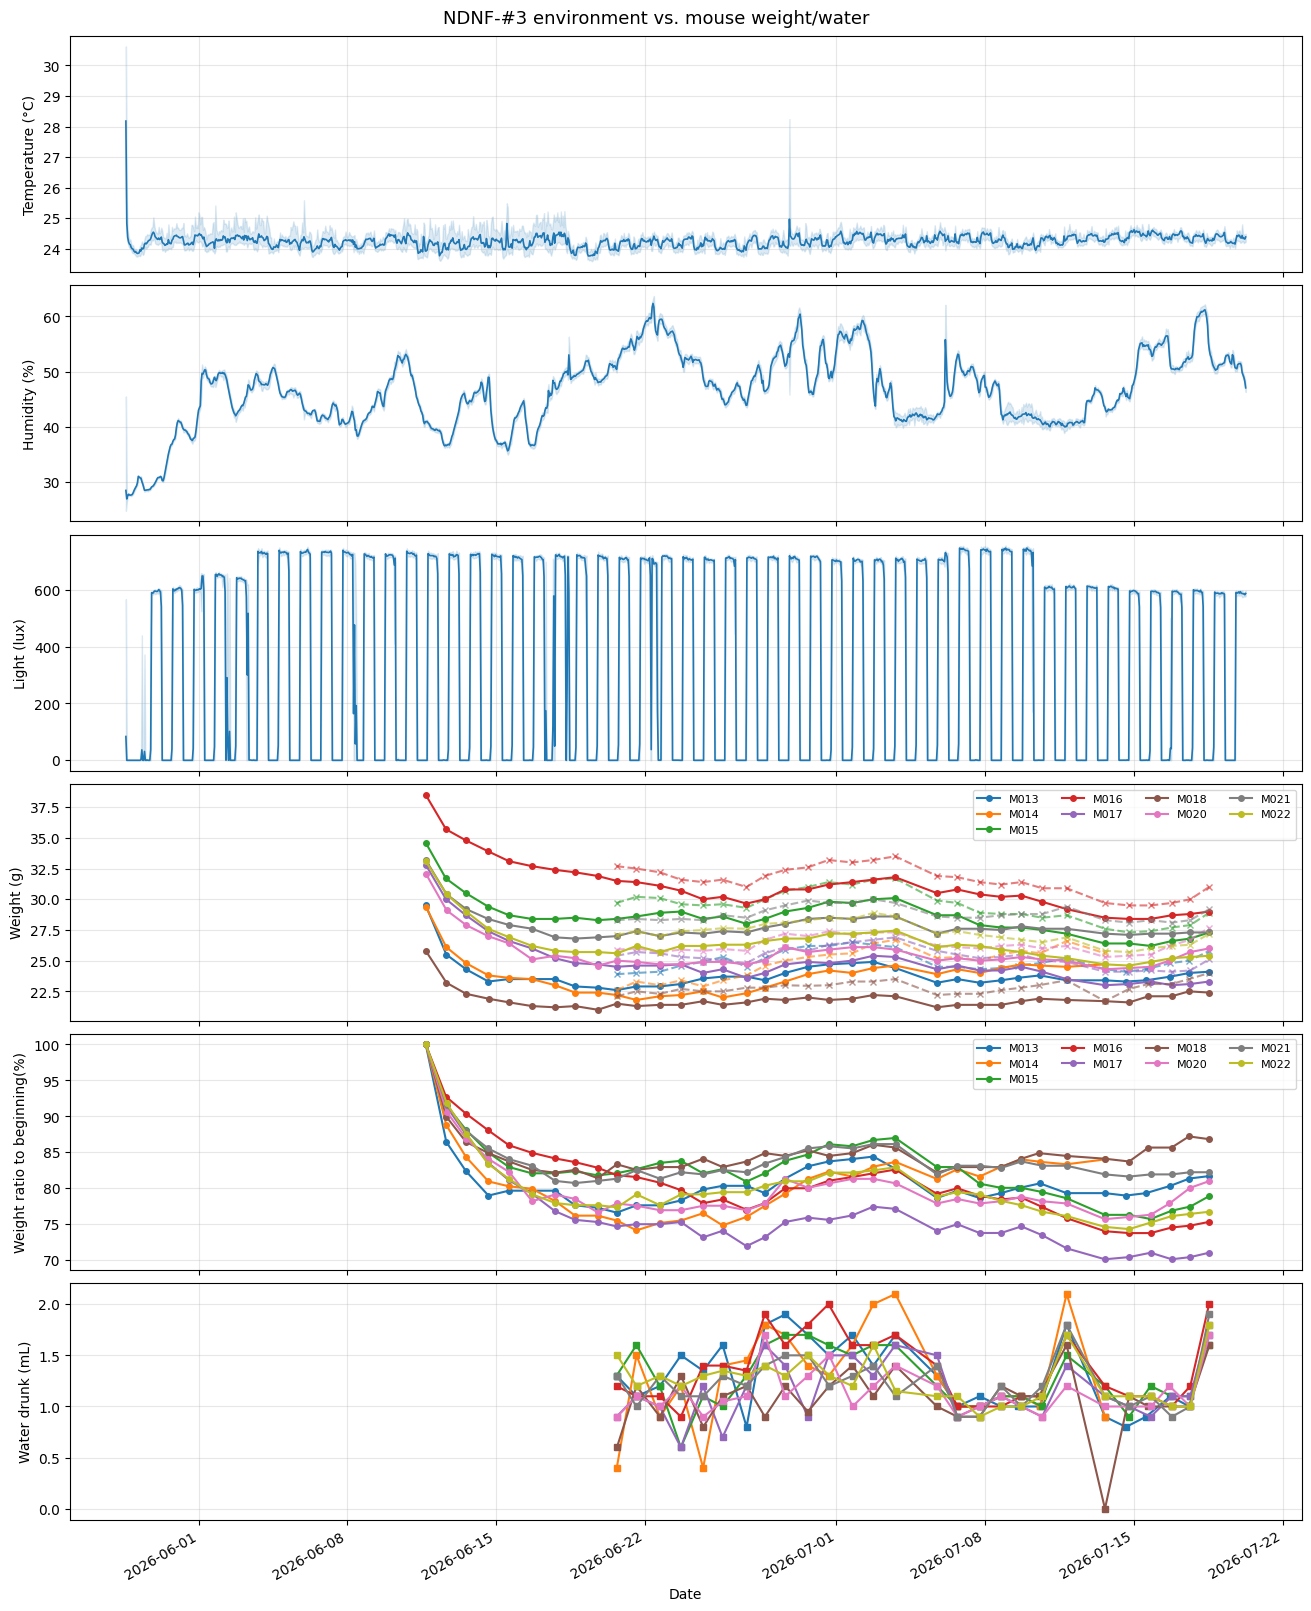

In [9]:
sensor_id = 'NDNF-#3'
group_id = 0

# ---- 1. this sensor's chosen recording block ----
times = (environment.EnvSensorRecording & {'sensor_id': sensor_id}).fetch('recording_datetime')
times = pd.to_datetime(pd.Series(times)).sort_values().reset_index(drop=True)
gap_threshold = pd.Timedelta(hours=1.5)
group_ids = (times.diff() > gap_threshold).cumsum()
first_run = times[group_ids == group_id]
env_start, env_end = first_run.min(), first_run.max()
print(f"Using {sensor_id}, window {env_start} to {env_end}")

# ---- 2. environment channels for that sensor + period ----
channels_of_interest = ['Temperature', 'Humidity', 'Light']
units = {'Temperature': '°C', 'Humidity': '%', 'Light': 'lux'}

env_df = ((environment.EnvSensorRecording.Channel & {'sensor_id': sensor_id})
          & f"channel_name in {tuple(channels_of_interest)}"
          & f"recording_datetime between '{env_start}' and '{env_end}'"
          ).fetch(format='frame').reset_index()
env_df['recording_datetime'] = pd.to_datetime(env_df['recording_datetime'])
env_df = env_df.sort_values('recording_datetime')

# ---- 3. water restriction logs in the same period ----
wr_log = (lab.WaterRestriction.WaterRestrictionLog
          & f"log_datetime between '{env_start}' and '{env_end}'").fetch(format='frame').reset_index()
for col in ['weight', 'weight_after_watering', 'water_given']:
    wr_log[col] = pd.to_numeric(wr_log[col], errors='coerce')
wr_log['log_datetime'] = pd.to_datetime(wr_log['log_datetime'])
wr_log = wr_log.sort_values(['subject_id', 'log_datetime'])

# ---- 3b. insert synthetic "no recording" logs for each skipped day ----
# one_day = pd.Timedelta(days=1)

# synthetic_rows = []
# for subject_id, grp in wr_log.groupby('subject_id'):
#     grp = grp.sort_values('log_datetime').reset_index(drop=True)
#     for i in range(len(grp) - 1):
#         t0, t1 = grp.loc[i], grp.loc[i + 1]
#         gap = t1['log_datetime'] - t0['log_datetime']
#         n_missing = round(gap / one_day) - 1  # e.g. gap ~2 days -> 1 missing log, ~3 days -> 2 missing logs
#         if n_missing < 1:
#             continue
#         for k in range(1, n_missing + 1):
#             frac = k / (n_missing + 1)
#             interp_weight = t0['weight'] + (t1['weight'] - t0['weight']) * frac
#             synthetic_rows.append({
#                 'subject_id': subject_id,
#                 'water_restriction_id': t0['water_restriction_id'],
#                 'log_datetime': t0['log_datetime'] + gap * frac,
#                 'user_name': 'synthetic',
#                 'weight': interp_weight,
#                 'weight_after_watering': interp_weight,
#                 'water_given': 0.0,
#                 'water_earned': None,
#                 'notes': f'inferred: no log recorded this day ({k}/{n_missing})',
#             })

# # if synthetic_rows:
# #     wr_log = pd.concat([wr_log, pd.DataFrame(synthetic_rows)], ignore_index=True)
# #     wr_log = wr_log.sort_values(['subject_id', 'log_datetime']).reset_index(drop=True)

mice = sorted(wr_log['subject_id'].unique())
colors = plt.cm.tab10.colors

# ---- 4. plot ----
fig, axes = plt.subplots(6, 1, figsize=(13, 16), sharex=True, constrained_layout=True)

for ax, channel in zip(axes[:3], channels_of_interest):
    sub = env_df[env_df['channel_name'] == channel]
    ax.plot(sub['recording_datetime'], sub['value_avg'], color='tab:blue', linewidth=1.2)
    ax.fill_between(sub['recording_datetime'], sub['value_min'], sub['value_max'], color='tab:blue', alpha=0.15)
    ax.set_ylabel(f"{channel} ({units[channel]})")
    ax.grid(alpha=0.3)

ax_weight = axes[3]
for i, subject_id in enumerate(mice):
    s = wr_log[wr_log['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax_weight.plot(s['log_datetime'], s['weight'], 'o-', color=color, label=subject_id, markersize=4)
    if s['weight_after_watering'].notna().any():
        ax_weight.plot(s['log_datetime'], s['weight_after_watering'], 'x--', color=color, markersize=4, alpha=0.6)
ax_weight.set_ylabel('Weight (g)')
ax_weight.grid(alpha=0.3)
ax_weight.legend(loc='upper right', ncol=min(len(mice), 4), fontsize=8)

ax_weight = axes[4]
for i, subject_id in enumerate(mice):
    s = wr_log[wr_log['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax_weight.plot(s['log_datetime'], s['weight']/s['weight'].iloc[0]*100, 'o-', color=color, label=subject_id, markersize=4)
ax_weight.set_ylabel('Weight ratio to beginning(%)')
ax_weight.grid(alpha=0.3)
ax_weight.legend(loc='upper right', ncol=min(len(mice), 4), fontsize=8)

ax_water = axes[5]
for i, subject_id in enumerate(mice):
    s = wr_log[wr_log['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax_water.plot(s['log_datetime'], s['weight_after_watering']-s['weight'], 's-', color=color, markersize=4)
ax_water.set_ylabel('Water drunk (mL)')
ax_water.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle(f'{sensor_id} environment vs. mouse weight/water', fontsize=13)
#plt.tight_layout()
plt.show()

In [10]:
wr_log

,subject_id,water_restriction_id,log_datetime,user_name,weight,weight_after_watering,water_given,water_earned,notes
0,M013,M013,2026-06-11 16:30:00,ridas,29.5,NaN,0.0,None,First day of water restriction- scruffy coat
1,M013,M013,2026-06-12 15:40:59,rozmar,25.5,NaN,0.8,None,mouse drinking well
2,M013,M013,2026-06-13 13:55:10,rozmar,24.3,NaN,0.5,None,
3,M013,M013,2026-06-14 15:16:29,ridas,23.3,NaN,3.0,None,giving back water for 5 minutes
4,M013,M013,2026-06-15 14:12:44,ridas,23.5,NaN,2.0,None,weight after water = 25
...,...,...,...,...,...,...,...,...,...
314,M022,M022,2026-07-14 18:28:22,rozmar,24.6,25.7,1.0,None,
315,M022,M022,2026-07-15 18:46:57,tchaves,24.9,26.0,1.0,None,
316,M022,M022,2026-07-16 18:31:57,tchaves,25.2,26.2,1.0,None,
317,M022,M022,2026-07-17 15:25:15,rozmar,25.3,26.3,1.0,None,


In [11]:
# ---- merge in date_of_birth and convert to age (days) at each log ----

dob_df = lab.Subject().fetch(format='frame')[['date_of_birth']].reset_index()
wr_log = wr_log.merge(dob_df, on='subject_id', how='left')
wr_log['date_of_birth'] = pd.to_datetime(wr_log['date_of_birth'])
wr_log['age_days'] = (wr_log['log_datetime'] - wr_log['date_of_birth']).dt.days

wr_log[['subject_id', 'log_datetime', 'date_of_birth', 'age_days']].head()

,subject_id,log_datetime,date_of_birth,age_days
0,M013,2026-06-11 16:30:00,2026-02-04,127
1,M013,2026-06-12 15:40:59,2026-02-04,128
2,M013,2026-06-13 13:55:10,2026-02-04,129
3,M013,2026-06-14 15:16:29,2026-02-04,130
4,M013,2026-06-15 14:12:44,2026-02-04,131


In [12]:
wr_master = lab.WaterRestriction().fetch(format='frame').reset_index()
wr_master['wr_start_weight'] = pd.to_numeric(wr_master['wr_start_weight'], errors='coerce')

wr_log = wr_log.merge(wr_master[['subject_id', 'water_restriction_id', 'wr_start_weight']],
                       on=['subject_id', 'water_restriction_id'], how='left')
wr_log = wr_log.sort_values(['subject_id', 'log_datetime'])

outlier_ids = ['M018', 'M021']

transitions = []
for subject_id, grp in wr_log.groupby('subject_id'):
    # if subject_id in outlier_ids:
    #     continue
    grp = grp.sort_values('log_datetime').reset_index(drop=True)
    for i in range(len(grp) - 1):
        t, t1 = grp.loc[i], grp.loc[i + 1]
        if pd.isna(t['weight_after_watering']):
            continue
        elapsed_days = (t1['log_datetime'] - t['log_datetime']).total_seconds() / 86400
        if elapsed_days <= 0:
            continue
        decay = t['weight_after_watering'] - t1['weight']
        transitions.append({
            'subject_id': subject_id,
            't_start': t['log_datetime'],
            't_end': t1['log_datetime'],
            'elapsed_days': elapsed_days,
            'water_given_t': t['weight_after_watering']-t['weight'],
            'decay': decay,
            'wr_start_weight': t['wr_start_weight'],
            'weight_t': t['weight'],
            'age_days': t['age_days'],
            'weight_ratio_t': t['weight'] / t['wr_start_weight'],
            'net_change': t1['weight'] - t['weight'],
        })

transitions = pd.DataFrame(transitions)
sex_df = lab.Subject().fetch(format='frame')[['sex']].reset_index()[['subject_id', 'sex']]
transitions = transitions.merge(sex_df, on='subject_id', how='left')

print(transitions.shape)

(229, 12)


In [13]:
sensor_id = 'NDNF-#3'

env_all = ((environment.EnvSensorRecording.Channel & {'sensor_id': sensor_id})
           & "channel_name in ('Temperature', 'Humidity')").fetch(format='frame').reset_index()
env_all['recording_datetime'] = pd.to_datetime(env_all['recording_datetime'])

def get_env_means(t_start, t_end):
    mask = (env_all['recording_datetime'] >= t_start) & (env_all['recording_datetime'] < t_end)
    sub = env_all[mask]
    return pd.Series({
        'mean_temp': sub.loc[sub['channel_name'] == 'Temperature', 'value_avg'].mean(),
        'mean_humidity': sub.loc[sub['channel_name'] == 'Humidity', 'value_avg'].mean(),
    })

env_features = transitions.apply(lambda r: get_env_means(r['t_start'], r['t_end']), axis=1)
transitions = pd.concat([transitions, env_features], axis=1).dropna(subset=['mean_temp', 'mean_humidity'])
print("Transition table shape: ", transitions.shape)
transitions.head(10)

Transition table shape:  (229, 14)


,subject_id,t_start,t_end,elapsed_days,water_given_t,decay,wr_start_weight,weight_t,age_days,weight_ratio_t,net_change,sex,mean_temp,mean_humidity
0,M013,2026-06-20 16:03:44,2026-06-21 14:21:25,0.928947,1.30,1.00,29.5,22.60,136,0.766102,0.30,M,24.146168,54.126832
1,M013,2026-06-21 14:21:25,2026-06-22 16:45:35,1.100116,1.10,1.10,29.5,22.90,137,0.776271,0.00,M,24.230500,58.369735
2,M013,2026-06-22 16:45:35,2026-06-23 16:33:20,0.991493,1.20,1.00,29.5,22.90,138,0.776271,0.20,M,24.170808,56.684338
3,M013,2026-06-23 16:33:20,2026-06-24 17:33:54,1.042060,1.50,1.05,29.5,23.10,139,0.783051,0.45,M,24.188056,51.910056
4,M013,2026-06-24 17:33:54,2026-06-25 15:35:14,0.917593,1.35,1.20,29.5,23.55,140,0.798305,0.15,M,24.154786,47.287800
5,M013,2026-06-25 15:35:14,2026-06-26 18:37:40,1.126690,1.60,1.60,29.5,23.70,141,0.803390,0.00,M,24.090363,45.652930
6,M013,2026-06-26 18:37:40,2026-06-27 15:17:18,0.860856,0.80,1.10,29.5,23.70,142,0.803390,-0.30,M,24.195924,48.270343
7,M013,2026-06-27 15:17:18,2026-06-28 14:13:22,0.955602,1.80,1.20,29.5,23.40,143,0.793220,0.60,M,24.226700,51.417713
8,M013,2026-06-28 14:13:22,2026-06-29 15:51:35,1.068206,1.90,1.40,29.5,24.00,144,0.813559,0.50,M,24.289496,55.024996
9,M013,2026-06-29 15:51:35,2026-06-30 15:27:17,0.983125,1.70,1.50,29.5,24.50,145,0.830508,0.20,M,24.236333,50.085567


Not much trend here...

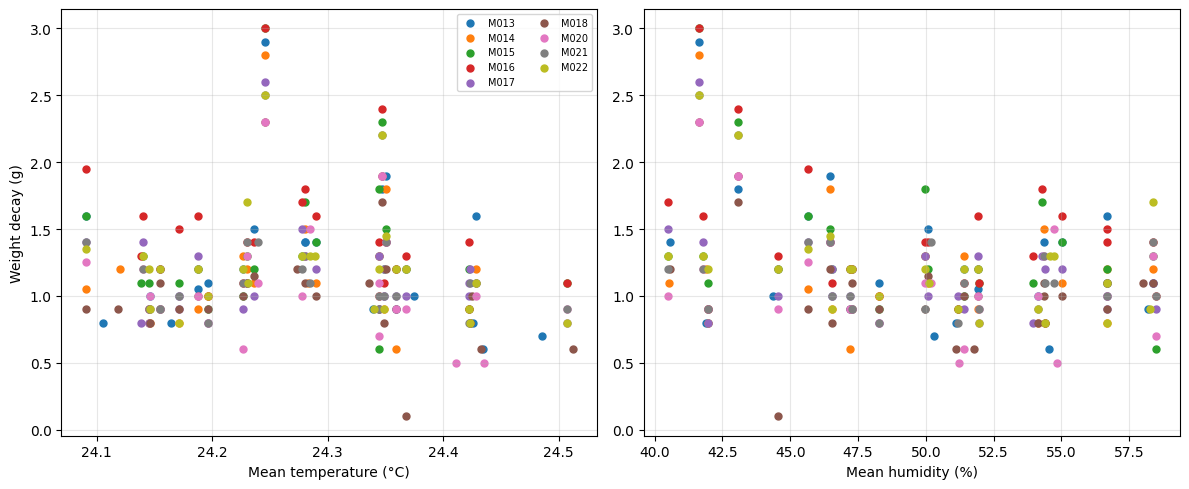

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10.colors
mice = sorted(transitions['subject_id'].unique())

for i, subject_id in enumerate(mice):
    s = transitions[transitions['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    axes[0].scatter(s['mean_temp'], s['decay'], color=color, label=subject_id, s=25)
    axes[1].scatter(s['mean_humidity'], s['decay'], color=color, s=25)

axes[0].set_xlabel('Mean temperature (°C)'); axes[0].set_ylabel('Weight decay (g)')
axes[1].set_xlabel('Mean humidity (%)')
axes[0].legend(fontsize=7, ncol=2)
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

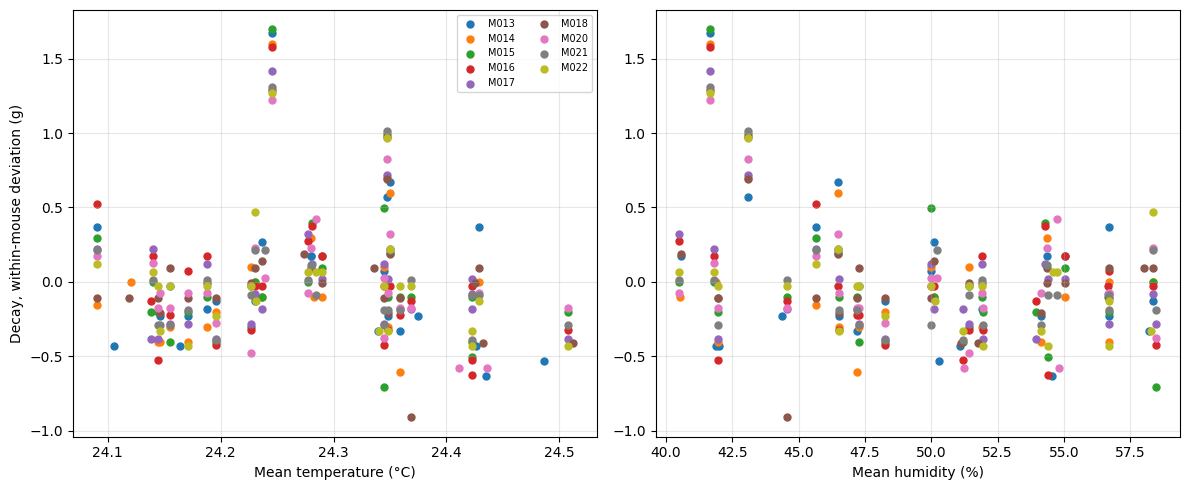

In [15]:
transitions['decay_centered'] = transitions.groupby('subject_id')['decay'].transform(lambda x: x - x.mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10.colors
mice = sorted(transitions['subject_id'].unique())

for i, subject_id in enumerate(mice):
    s = transitions[transitions['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    axes[0].scatter(s['mean_temp'], s['decay_centered'], color=color, label=subject_id, s=25)
    axes[1].scatter(s['mean_humidity'], s['decay_centered'], color=color, s=25)

axes[0].set_xlabel('Mean temperature (°C)')
axes[0].set_ylabel('Decay, within-mouse deviation (g)')
axes[1].set_xlabel('Mean humidity (%)')
axes[0].legend(fontsize=7, ncol=2)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

y_ij = β₀ + β₁·mean_temp_ij + β₂·mean_humidity_ij + β₃·weight_ratio_t_ij + ... + b_i + ε_ij

Here y_ij is decay (target) for that transition, i indexes the mouse, j indexes the transition within that mouse.

β₀, β₁, β₂, β₃ are the fixed effects — the "Intercept", mean_temp, mean_humidity, and weight_ratio_t rows in the summary output. These are population-level coefficients: one shared value for all mice, telling you how decay changes on average per unit of temperature, humidity, or weight ratio, holding the others fixed.

b_i is the random intercept for mouse i — a mouse-specific offset from the population intercept β₀, capturing that this particular mouse tends to run systematically higher or lower than average, independent of temp/humidity/weight state. It's assumed to be drawn from the same normal distribution for every mouse, b_i ~ N(0, τ²), where τ² (reported as "Group Var" in the summary) is the variance of that distribution — how much mice typically differ from one another. Unlike β, b_i isn't a free parameter estimated independently for each mouse; it's a random variable, and what gets computed for each training mouse is a prediction of its particular realization, not a "fit" in the usual sense.

ε_ij is the observation-level residual noise for transition j of mouse i — everything left over after the fixed effects and that mouse's intercept are accounted for. It's ε_ij ~ N(0, σ²) (σ² is "Scale" in the summary), independent across every single observation, and independent of b_i.

Together, b_i and ε_ij are what create the within-mouse correlation structure: two rows from the same mouse share the same b_i, so they're correlated (by τ²/(τ²+σ²)); two rows from different mice share nothing, so they're uncorrelated.

In [16]:
import statsmodels.formula.api as smf

model = smf.mixedlm("decay ~ standardize(mean_temp) + standardize(mean_humidity) + standardize(weight_t) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(wr_start_weight) + standardize(age_days)",
                     data=transitions, groups=transitions["subject_id"], re_formula=None)
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       decay  
No. Observations:       229           Method:                   REML   
No. Groups:             9             Scale:                    0.0367 
Min. group size:        21            Log-Likelihood:           24.4052
Max. group size:        26            Converged:                Yes    
Mean group size:        25.4                                           
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     1.206    0.040 29.819 0.000  1.127  1.285
standardize(mean_temp)       -0.042    0.015 -2.854 0.004 -0.071 -0.013
standardize(mean_humidity)   -0.008    0.015 -0.535 0.592 -0.038  0.022
standardize(weight_t)         0.293    0.048  6.039 0.000  0.198  0.387
standardi

In [17]:
def compute_metrics(cv_results):
    actual = cv_results['actual']
    predicted = cv_results['predicted']
    error = actual - predicted

    mae = error.abs().mean()
    rmse = np.sqrt((error ** 2).mean())
    corr = actual.corr(predicted)  # Pearson r: do predicted values move with actual ones?
    ss_res = (error ** 2).sum()
    ss_tot = ((actual - actual.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot  # fraction of variance in 'actual' explained by 'predicted'

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'corr': corr}

In [18]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def cross_validate_leave_one_mouse_out(transitions, formula, target_col='decay', re_formula = None):
    predictions = []
    for held_out in transitions['subject_id'].unique():
        train = transitions[transitions['subject_id'] != held_out]
        test = transitions[transitions['subject_id'] == held_out]
        if test.empty or train['subject_id'].nunique() < 2:
            continue
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            m = smf.mixedlm(formula, data=train, groups=train["subject_id"], re_formula=re_formula).fit()
        if any("failed to converge" in str(w.message) for w in caught):
            print(f"Optimization failed for held-out mouse {held_out} (formula: {formula})")
        for w in caught:
            print(f"[held out: {held_out}] {w.category.__name__}: {w.message}")
        pred = m.predict(test)
        predictions.append(pd.DataFrame({'subject_id': held_out, 'actual': test[target_col], 'predicted': pred}))

    cv_results = pd.concat(predictions)
    errors = compute_metrics(cv_results)
    return cv_results, errors

In [19]:
transitions = transitions.sort_values(['subject_id', 't_start']).reset_index(drop=True)

# --- naive baseline 1: expanding (causal) mean of past decay values per mouse ---
transitions['naive_expanding_pred'] = (
    transitions.groupby('subject_id')['decay']
               .transform(lambda x: x.shift(1).expanding().mean())
)
valid_expanding = transitions['naive_expanding_pred'].notna()
cv_results_naive_expanding = (
    transitions.loc[valid_expanding, ['subject_id', 'decay', 'naive_expanding_pred']]
    .rename(columns={'decay': 'actual', 'naive_expanding_pred': 'predicted'})
)
errors_naive_expanding = compute_metrics(cv_results_naive_expanding)

# --- naive baseline 2: mouse's own overall mean decay ---
transitions['naive_mean_pred'] = transitions.groupby('subject_id')['decay'].transform('mean')
cv_results_naive_mean = (
    transitions[['subject_id', 'decay', 'naive_mean_pred']]
    .rename(columns={'decay': 'actual', 'naive_mean_pred': 'predicted'})
)
errors_naive_mean = compute_metrics(cv_results_naive_mean)

[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M021] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M021] ConvergenceWarning: The MLE may be on the boundary of the parameter space.


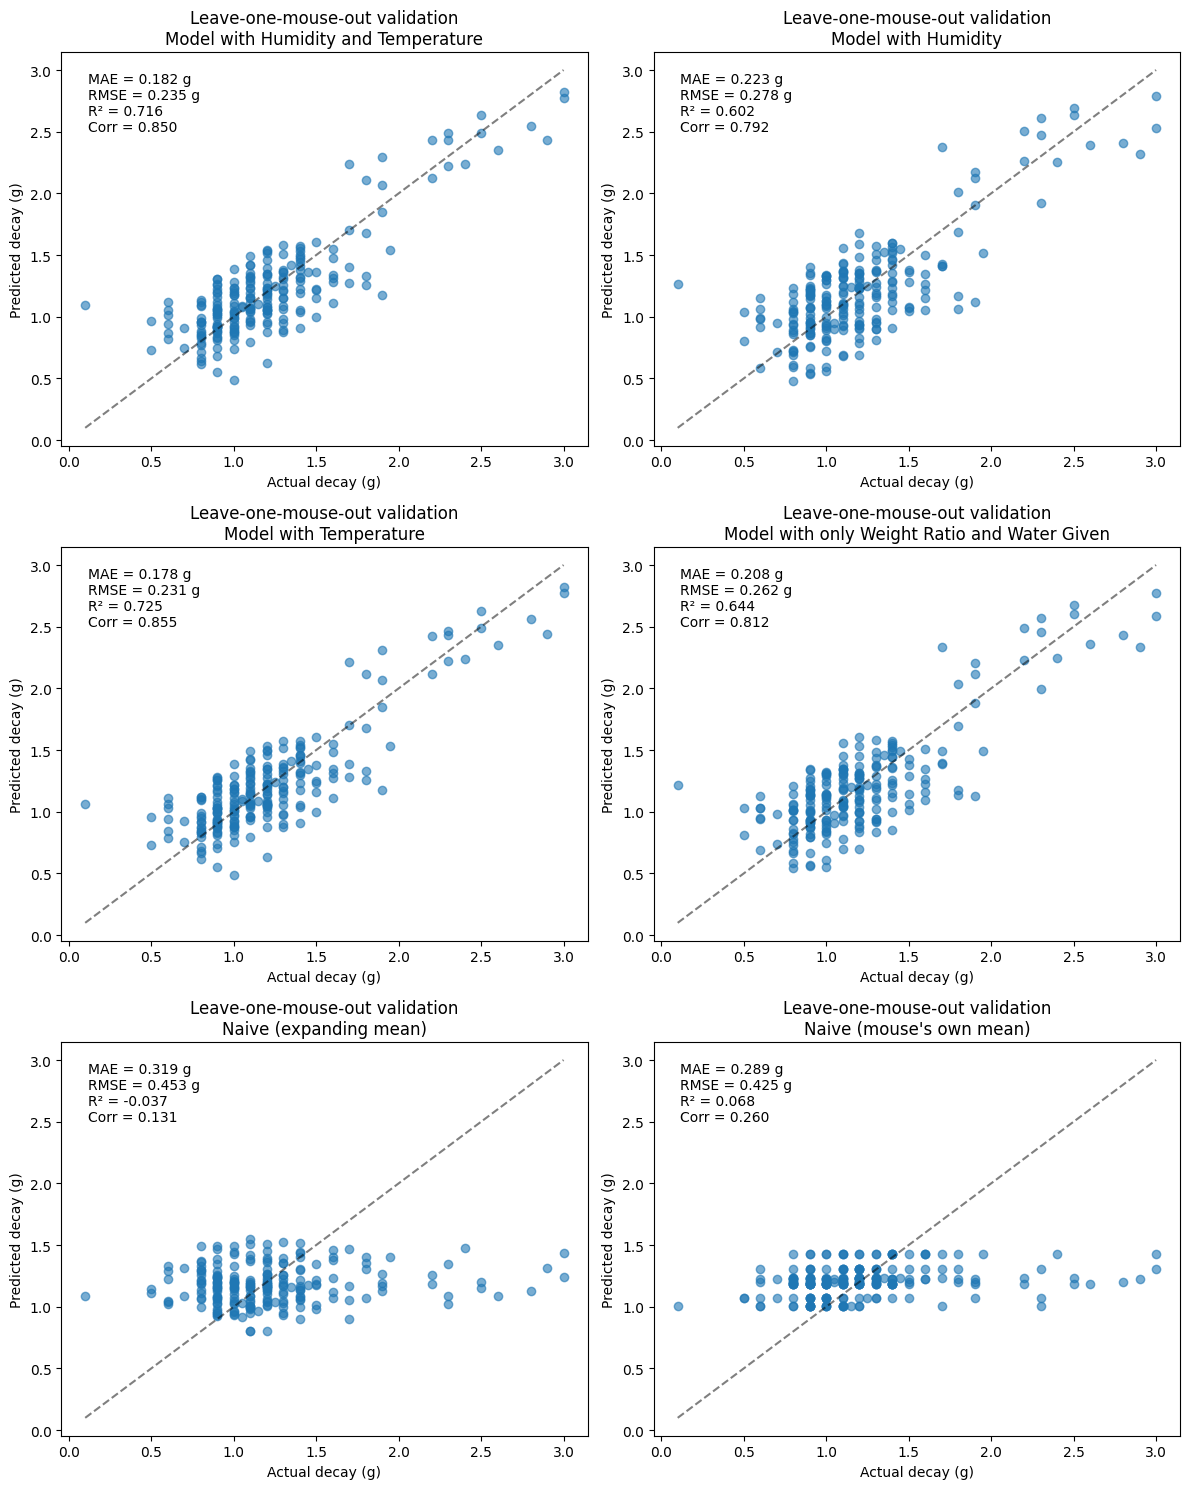

In [20]:
cv_results_ht, errors_ht = cross_validate_leave_one_mouse_out(transitions, "decay ~ standardize(mean_temp) + standardize(mean_humidity) + standardize(weight_t) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(wr_start_weight) + standardize(age_days)")
cv_results_h, errors_h = cross_validate_leave_one_mouse_out(transitions, "decay ~ standardize(mean_humidity) + standardize(weight_t) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(wr_start_weight) + standardize(age_days)")
cv_results_t, errors_t = cross_validate_leave_one_mouse_out(transitions, "decay ~ standardize(mean_temp) + standardize(weight_t) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(wr_start_weight) + standardize(age_days)")
cv_results, errors = cross_validate_leave_one_mouse_out(transitions, "decay ~ standardize(weight_t) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(wr_start_weight) + standardize(age_days)")

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

axes[0, 0].scatter(cv_results_ht['actual'], cv_results_ht['predicted'], alpha=0.6)
lims = [cv_results_ht[['actual', 'predicted']].min().min(), cv_results_ht[['actual', 'predicted']].max().max()]
axes[0, 0].plot(lims, lims, 'k--', alpha=0.5)
axes[0, 0].set_xlabel('Actual decay (g)')
axes[0, 0].set_ylabel('Predicted decay (g)')
axes[0, 0].set_title('Leave-one-mouse-out validation\nModel with Humidity and Temperature')
axes[0, 0].text(0.05, 0.95, f'MAE = {errors_ht["mae"]:.3f} g\nRMSE = {errors_ht["rmse"]:.3f} g\nR² = {errors_ht["r2"]:.3f}\nCorr = {errors_ht["corr"]:.3f}', transform=axes[0, 0].transAxes,
                ha='left', va='top')

axes[0, 1].scatter(cv_results_h['actual'], cv_results_h['predicted'], alpha=0.6)
lims = [cv_results_h[['actual', 'predicted']].min().min(), cv_results_h[['actual', 'predicted']].max().max()]
axes[0, 1].plot(lims, lims, 'k--', alpha=0.5)
axes[0, 1].set_xlabel('Actual decay (g)')
axes[0, 1].set_ylabel('Predicted decay (g)')
axes[0, 1].set_title('Leave-one-mouse-out validation\nModel with Humidity')
axes[0, 1].text(0.05, 0.95, f'MAE = {errors_h["mae"]:.3f} g\nRMSE = {errors_h["rmse"]:.3f} g\nR² = {errors_h["r2"]:.3f}\nCorr = {errors_h["corr"]:.3f}', transform=axes[0, 1].transAxes,
                ha='left', va='top')

axes[1, 0].scatter(cv_results_t['actual'], cv_results_t['predicted'], alpha=0.6)
lims = [cv_results_t[['actual', 'predicted']].min().min(), cv_results_t[['actual', 'predicted']].max().max()]
axes[1, 0].plot(lims, lims, 'k--', alpha=0.5)
axes[1, 0].set_xlabel('Actual decay (g)')
axes[1, 0].set_ylabel('Predicted decay (g)')
axes[1, 0].set_title('Leave-one-mouse-out validation\nModel with Temperature')
axes[1, 0].text(0.05, 0.95, f'MAE = {errors_t["mae"]:.3f} g\nRMSE = {errors_t["rmse"]:.3f} g\nR² = {errors_t["r2"]:.3f}\nCorr = {errors_t["corr"]:.3f}', transform=axes[1, 0].transAxes,
                ha='left', va='top')

axes[1, 1].scatter(cv_results['actual'], cv_results['predicted'], alpha=0.6)
lims = [cv_results[['actual', 'predicted']].min().min(), cv_results[['actual', 'predicted']].max().max()]
axes[1, 1].plot(lims, lims, 'k--', alpha=0.5)
axes[1, 1].set_xlabel('Actual decay (g)')
axes[1, 1].set_ylabel('Predicted decay (g)')
axes[1, 1].set_title('Leave-one-mouse-out validation\nModel with only Weight Ratio and Water Given')
axes[1, 1].text(0.05, 0.95, f'MAE = {errors["mae"]:.3f} g\nRMSE = {errors["rmse"]:.3f} g\nR² = {errors["r2"]:.3f}\nCorr = {errors["corr"]:.3f}', transform=axes[1, 1].transAxes,
                ha='left', va='top')

axes[2, 0].scatter(cv_results_naive_expanding['actual'], cv_results_naive_expanding['predicted'], alpha=0.6)
lims = [cv_results_naive_expanding[['actual', 'predicted']].min().min(), cv_results_naive_expanding[['actual', 'predicted']].max().max()]
axes[2, 0].plot(lims, lims, 'k--', alpha=0.5)
axes[2, 0].set_xlabel('Actual decay (g)')
axes[2, 0].set_ylabel('Predicted decay (g)')
axes[2, 0].set_title('Leave-one-mouse-out validation\nNaive (expanding mean)')
axes[2, 0].text(0.05, 0.95, f'MAE = {errors_naive_expanding["mae"]:.3f} g\nRMSE = {errors_naive_expanding["rmse"]:.3f} g\nR² = {errors_naive_expanding["r2"]:.3f}\nCorr = {errors_naive_expanding["corr"]:.3f}', transform=axes[2, 0].transAxes,
                ha='left', va='top')

axes[2, 1].scatter(cv_results_naive_mean['actual'], cv_results_naive_mean['predicted'], alpha=0.6)
lims = [cv_results_naive_mean[['actual', 'predicted']].min().min(), cv_results_naive_mean[['actual', 'predicted']].max().max()]
axes[2, 1].plot(lims, lims, 'k--', alpha=0.5)
axes[2, 1].set_xlabel('Actual decay (g)')
axes[2, 1].set_ylabel('Predicted decay (g)')
axes[2, 1].set_title('Leave-one-mouse-out validation\nNaive (mouse\'s own mean)')
axes[2, 1].text(0.05, 0.95, f'MAE = {errors_naive_mean["mae"]:.3f} g\nRMSE = {errors_naive_mean["rmse"]:.3f} g\nR² = {errors_naive_mean["r2"]:.3f}\nCorr = {errors_naive_mean["corr"]:.3f}', transform=axes[2, 1].transAxes,
                ha='left', va='top')

plt.tight_layout()
plt.show()

Just a check if the target variable is the net change

Text(0.05, 0.95, 'MAE = 0.223 g\nRMSE = 0.278 g\nR² = 0.496\nCorr = 0.751')

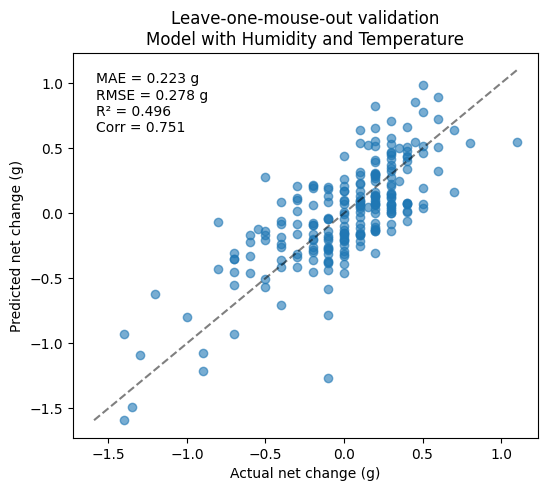

In [21]:
cv_results_net, errors_net = cross_validate_leave_one_mouse_out(transitions, "net_change ~ standardize(mean_humidity) + standardize(weight_t) + standardize(elapsed_days) + standardize(water_given_t) + standardize(wr_start_weight) + C(sex) + standardize(age_days)", target_col='net_change')

fig, axes = plt.subplots(1, 1, figsize=(6, 5))

axes.scatter(cv_results_net['actual'], cv_results_net['predicted'], alpha=0.6)
lims = [cv_results_net[['actual', 'predicted']].min().min(), cv_results_net[['actual', 'predicted']].max().max()]
axes.plot(lims, lims, 'k--', alpha=0.5)
axes.set_xlabel('Actual net change (g)')
axes.set_ylabel('Predicted net change (g)')
axes.set_title('Leave-one-mouse-out validation\nModel with Humidity and Temperature')
axes.text(0.05, 0.95, f'MAE = {errors_net["mae"]:.3f} g\nRMSE = {errors_net["rmse"]:.3f} g\nR² = {errors_net["r2"]:.3f}\nCorr = {errors_net["corr"]:.3f}', transform=axes.transAxes,
                ha='left', va='top')


In [22]:
def recommend_water_search(current_weight, wr_start_weight, target_pct, days_until_next,
                            mean_humidity_forecast, sex, model_result,
                            subject_id=None, lo=0.0, hi=3.0, tol=1e-3):
    target_weight_g = wr_start_weight * target_pct / 100

    # this mouse's own fitted random intercept, if it was in the training data
    b_i = 0.0
    if subject_id is not None and subject_id in model_result.random_effects:
        b_i = model_result.random_effects[subject_id]['Group']

    def predicted_weight_next(water_given):
        pred_decay = model_result.predict(pd.DataFrame({
            'mean_humidity': [mean_humidity_forecast],
            'weight_ratio_t': [current_weight / wr_start_weight],
            'water_given_t': [water_given],
            'elapsed_days': [days_until_next],
            'sex': [sex]
        })).iloc[0] + b_i
        return (current_weight + water_given) - pred_decay

    while hi - lo > tol:
        mid = (lo + hi) / 2
        if predicted_weight_next(mid) < target_weight_g:
            lo = mid   # predicted weight too low -> try more water
        else:
            hi = mid   # predicted weight too high -> try less water
    return (lo + hi) / 2

In [23]:
def recommend_water_simple(transitions, current_weight, wr_start_weight, target_pct, days_until_next, subject_id):
    mouse_avg_decay = transitions.groupby('subject_id')['decay'].mean()
    decay_rate = mouse_avg_decay.get(subject_id, transitions['decay'].mean())
    target_weight_g = wr_start_weight * target_pct / 100
    required_weight_after_watering = target_weight_g + decay_rate * days_until_next
    return max(required_weight_after_watering - current_weight, 0)

## Leave-one-covariate-out analysis

Starting from the full model (temperature + humidity + weight + water given + elapsed days + sex + starting weight), drop one predictor at a time and re-run the same leave-one-mouse-out cross-validation used above. This shows how much predictive performance each variable is actually contributing, rather than relying on in-sample significance alone.

In [24]:
full_terms = ['standardize(mean_temp)', 'standardize(mean_humidity)', 'standardize(weight_t)', 'standardize(water_given_t)', 'standardize(elapsed_days)', 'C(sex)', 'standardize(wr_start_weight)', 'standardize(age_days)']
full_formula = "decay ~ " + " + ".join(full_terms)

term_labels = {
    'standardize(mean_temp)': '- Temperature',
    'standardize(mean_humidity)': '- Humidity',
    'standardize(weight_t)': '- Weight',
    'standardize(water_given_t)': '- Water given',
    'standardize(elapsed_days)': '- Elapsed days',
    'C(sex)': '- Sex',
    'standardize(wr_start_weight)': '- Starting weight',
    'standardize(age_days)': '- Age (days)'
}

loco_results = {}

# full model
_, err_full = cross_validate_leave_one_mouse_out(transitions, full_formula)
loco_results['Full model'] = err_full

# drop one term at a time
for term in full_terms:
    reduced_terms = [t for t in full_terms if t != term]
    reduced_formula = "decay ~ " + " + ".join(reduced_terms)
    # if term == 'weight_t':
    #     _, err_reduced = cross_validate_leave_one_mouse_out(transitions, reduced_formula)
    # else:
    #     _, err_reduced = cross_validate_leave_one_mouse_out(transitions, reduced_formula, re_formula="~weight_t")
    _, err_reduced = cross_validate_leave_one_mouse_out(transitions, reduced_formula)
    loco_results[term_labels[term]] = err_reduced

loco_df = pd.DataFrame(loco_results).T
loco_df['delta_r2'] = loco_df['r2'] - loco_df.loc['Full model', 'r2']
loco_df = loco_df.sort_values('r2', ascending=False)
loco_df

[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M021] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M017] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
[held out: M021] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
Optimization failed for held-out mouse M013 (formula: decay ~ standardize(mean_temp) + standardize(mean_humidity) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(wr_start_weight) + standardize(age_days))
[held out: M013] ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
[held out: M013] ConvergenceWarning: Retrying MixedLM optimization with lbfgs
[held out: M013] ConvergenceWarning: The MLE may be on the boundary of the parameter space.
Optimization failed for held-out mouse M014 (formula: decay ~ standardize(mean_temp) + standardize(mean_humidity) + sta

,mae,rmse,r2,corr,delta_r2
- Weight,0.168697,0.218308,0.753872,0.868594,0.038284
- Age (days),0.175431,0.228363,0.730677,0.857203,0.015089
- Humidity,0.177865,0.230701,0.725135,0.854579,0.009546
Full model,0.181520,0.234673,0.715588,0.849726,0.000000
- Sex,0.181520,0.234673,0.715588,0.849726,0.000000
- Water given,0.197635,0.253616,0.667817,0.825069,-0.047771
- Temperature,0.223383,0.277570,0.602106,0.791773,-0.113483
- Starting weight,0.235235,0.286138,0.577162,0.809733,-0.138426
- Elapsed days,0.277383,0.360118,0.330252,0.590184,-0.385336


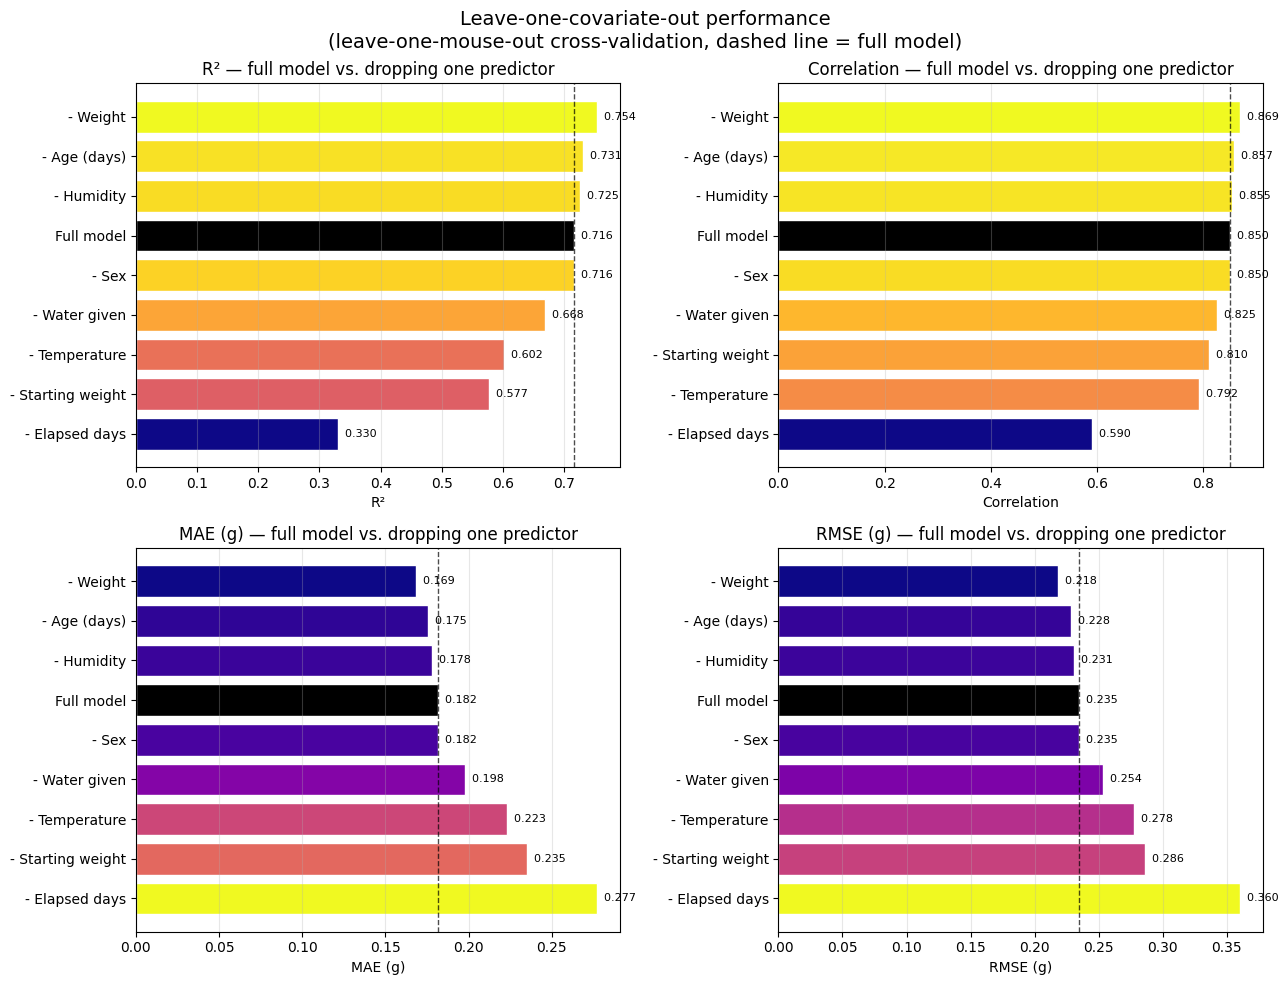

In [ ]:
# ---- full model vs. each drop-one-predictor model ----

metrics_to_plot = ['r2', 'corr', 'mae', 'rmse']
titles = {'r2': 'R²', 'corr': 'Correlation', 'mae': 'MAE (g)', 'rmse': 'RMSE (g)'}
higher_is_better = {'r2': True, 'corr': True, 'mae': False, 'rmse': False}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
cmap = plt.cm.plasma

for ax, metric in zip(axes.flat, metrics_to_plot):
    order = loco_df[metric].sort_values(ascending=not higher_is_better[metric]).index
    values = loco_df.loc[order, metric]
    span = values.max() - values.min()
    norm_vals = (values - values.min()) / (span if span > 0 else 1)
    colors = [cmap(v) for v in norm_vals]
    colors = ['black' if name == 'Full model' else c for name, c in zip(order, colors)]

    bars = ax.barh(order, values, color=colors, edgecolor='white')
    ax.axvline(loco_df.loc['Full model', metric], color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'{titles[metric]} — full model vs. dropping one predictor')
    ax.set_xlabel(titles[metric])
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'  {val:.3f}',
                va='center', ha='left', fontsize=8)

fig.suptitle('Leave-one-covariate-out performance\n(leave-one-mouse-out cross-validation, dashed line = full model)', fontsize=14)
plt.tight_layout()
plt.show()

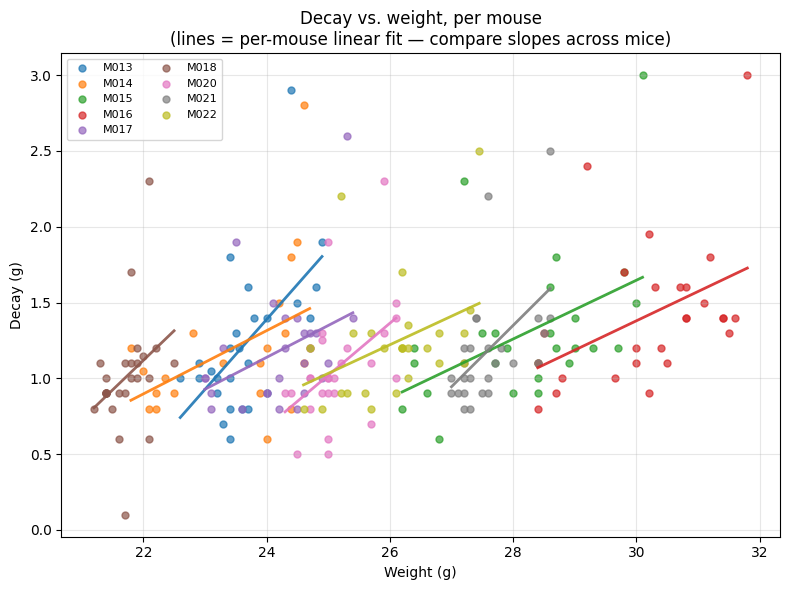

In [26]:
# ---- decay vs. weight_t, per mouse — is the slope actually consistent across mice? ----

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
mice = sorted(transitions['subject_id'].unique())

for i, subject_id in enumerate(mice):
    s = transitions[transitions['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax.scatter(s['weight_t'], s['decay'], color=color, label=subject_id, s=25, alpha=0.7)
    if len(s) > 1:
        coeffs = np.polyfit(s['weight_t'], s['decay'], 1)
        xs = np.linspace(s['weight_t'].min(), s['weight_t'].max(), 50)
        ax.plot(xs, np.polyval(coeffs, xs), color=color, linewidth=2, alpha=0.9)

ax.set_xlabel('Weight (g)')
ax.set_ylabel('Decay (g)')
ax.set_title('Decay vs. weight, per mouse\n(lines = per-mouse linear fit — compare slopes across mice)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualizing the fitted model

Three views of the final full model (`decay ~ mean_temp + mean_humidity + weight_t + wr_start_weight + water_given_t + elapsed_days + C(sex)`, random intercept per mouse): the fixed-effect coefficients themselves, how correlated the predictors are with each other, and the partial effect of each predictor on decay (the data with everything else's contribution removed, plotted against the fitted line).

In [27]:
model = smf.mixedlm("decay ~ standardize(mean_temp) + standardize(mean_humidity) + standardize(weight_t) + standardize(wr_start_weight) + standardize(water_given_t) + standardize(elapsed_days) + C(sex) + standardize(age_days)",
                     data=transitions, groups=transitions["subject_id"])
result = model.fit()
print(result.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       decay  
No. Observations:       229           Method:                   REML   
No. Groups:             9             Scale:                    0.0367 
Min. group size:        21            Log-Likelihood:           24.4052
Max. group size:        26            Converged:                Yes    
Mean group size:        25.4                                           
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     1.206    0.040 29.819 0.000  1.127  1.285
standardize(mean_temp)       -0.042    0.015 -2.854 0.004 -0.071 -0.013
standardize(mean_humidity)   -0.008    0.015 -0.535 0.592 -0.038  0.022
standardize(weight_t)         0.293    0.048  6.039 0.000  0.198  0.387
standardi

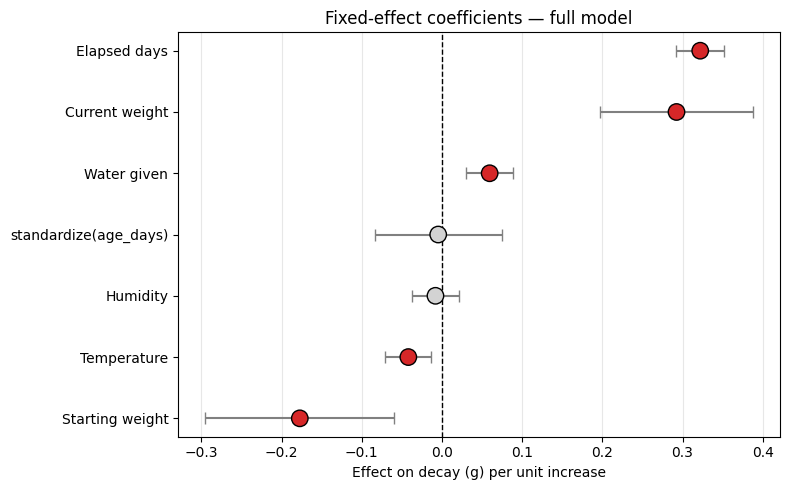

In [28]:
# ---- fixed-effect coefficients with 95% CI, full model ----

nice_names = {
    'standardize(mean_temp)': 'Temperature',
    'standardize(mean_humidity)': 'Humidity',
    'standardize(weight_t)': 'Current weight',
    'standardize(wr_start_weight)': 'Starting weight',
    'standardize(water_given_t)': 'Water given',
    'standardize(elapsed_days)': 'Elapsed days',
}
sex_terms = [t for t in result.fe_params.index if 'sex' in t.lower()]
if sex_terms:
    nice_names[sex_terms[0]] = 'Sex (M vs F)'
# (sex won't appear here at all if it has only one level in the current data)

fe_params = result.fe_params.drop('Intercept')
conf_int = result.conf_int().loc[fe_params.index]
pvalues = result.pvalues.loc[fe_params.index]

coef_df = pd.DataFrame({
    'coef': fe_params,
    'ci_low': conf_int[0],
    'ci_high': conf_int[1],
    'pvalue': pvalues,
})
coef_df.index = [nice_names.get(i, i) for i in coef_df.index]
coef_df = coef_df.sort_values('coef')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tab:red' if p < 0.05 else 'lightgray' for p in coef_df['pvalue']]
y_pos = np.arange(len(coef_df))
ax.errorbar(coef_df['coef'], y_pos,
            xerr=[coef_df['coef'] - coef_df['ci_low'], coef_df['ci_high'] - coef_df['coef']],
            fmt='none', ecolor='gray', capsize=4, zorder=2)
ax.scatter(coef_df['coef'], y_pos, color=colors, s=140, zorder=3, edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df.index)
ax.set_xlabel('Effect on decay (g) per unit increase')
ax.set_title('Fixed-effect coefficients — full model')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

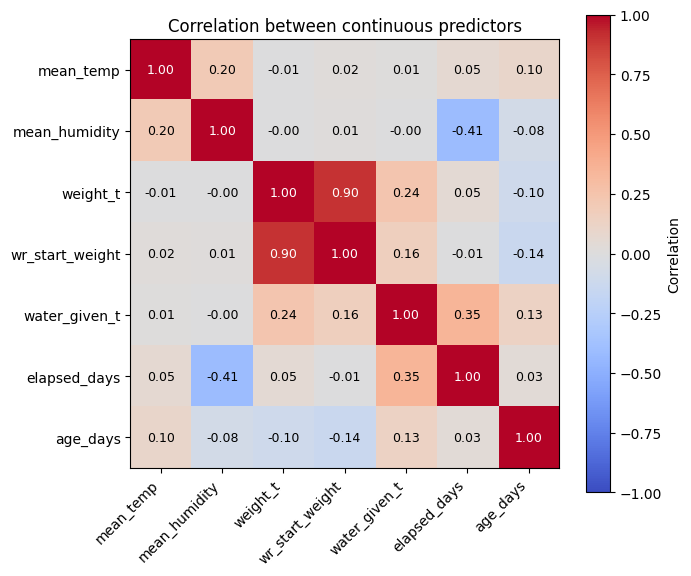

In [29]:
# ---- correlation among the continuous predictors ----
cont_vars = ['mean_temp', 'mean_humidity', 'weight_t', 'wr_start_weight', 'water_given_t', 'elapsed_days', 'age_days']
corr = transitions[cont_vars].corr()
labels_corr = [nice_names.get(v, v) for v in cont_vars]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cont_vars)))
ax.set_yticks(range(len(cont_vars)))
ax.set_xticklabels(labels_corr, rotation=45, ha='right')
ax.set_yticklabels(labels_corr)
for i in range(len(cont_vars)):
    for j in range(len(cont_vars)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation between continuous predictors')
plt.tight_layout()
plt.show()

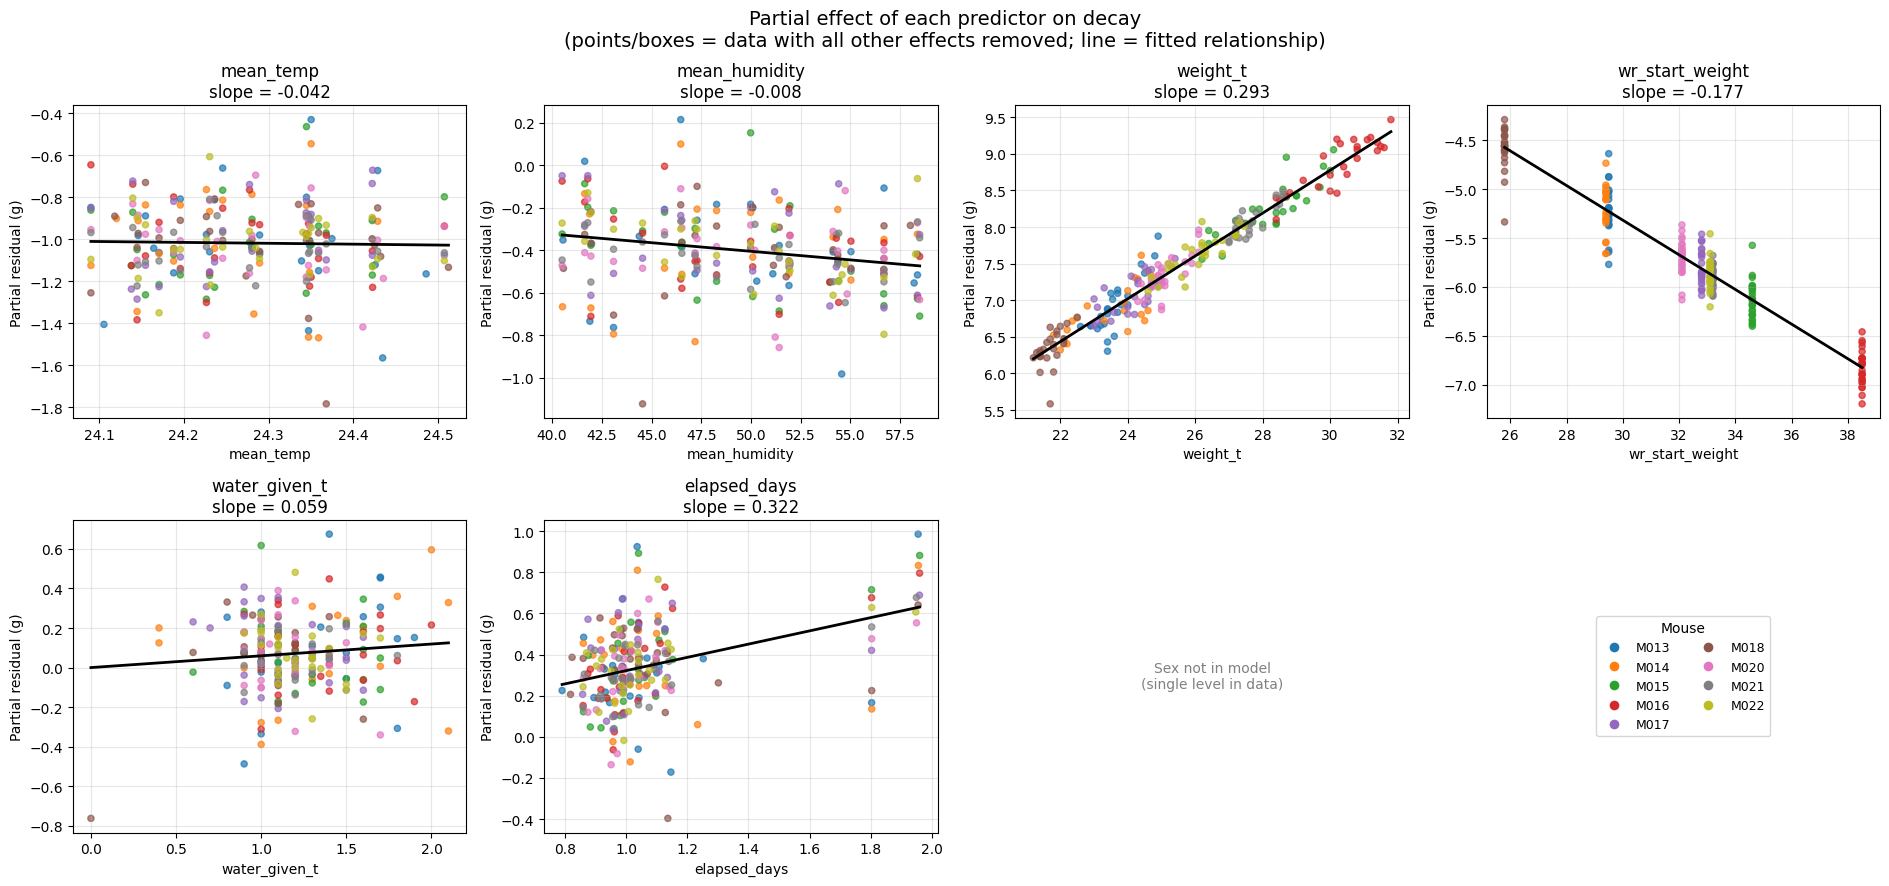

In [30]:
# ---- partial-effect plots: data with everything else removed, vs. each predictor ----

continuous_terms = ['mean_temp', 'mean_humidity', 'weight_t', 'wr_start_weight', 'water_given_t', 'elapsed_days']
resid = result.resid  # y - (fixed effects + b_i), i.e. an estimate of epsilon_ij

sex_terms = [t for t in result.fe_params.index if 'sex' in t.lower()]

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
mice = sorted(transitions['subject_id'].unique())
mouse_colors = {m: plt.cm.tab10.colors[i % 10] for i, m in enumerate(mice)}
point_colors = transitions['subject_id'].map(mouse_colors)

for ax, term in zip(axes.flat, continuous_terms):
    beta = result.fe_params[f'standardize({term})']
    partial_resid = resid + beta * transitions[term]
    ax.scatter(transitions[term], partial_resid, c=point_colors, s=20, alpha=0.7)
    xs = np.linspace(transitions[term].min(), transitions[term].max(), 50)
    ax.plot(xs, beta * xs, color='black', linewidth=2)
    ax.set_xlabel(nice_names.get(term, term))
    ax.set_ylabel('Partial residual (g)')
    ax.set_title(f'{nice_names.get(term, term)}\nslope = {beta:.3f}')
    ax.grid(alpha=0.3)

next_slot = 6

if sex_terms:
    # sex is categorical -> partial residual shown as a boxplot instead of a scatter
    sex_term = sex_terms[0]
    sex_category = sex_term.split('T.')[-1].rstrip(']')
    beta_sex = result.fe_params[f'standardize({sex_term})']
    sex_indicator = (transitions['sex'] == sex_category).astype(float)
    partial_resid_sex = resid + beta_sex * sex_indicator

    ax_sex = axes.flat[next_slot]
    groups_data = [partial_resid_sex[transitions['sex'] != sex_category], partial_resid_sex[transitions['sex'] == sex_category]]
    bp = ax_sex.boxplot(groups_data, labels=[f'not {sex_category}', sex_category], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['tab:blue', 'tab:orange']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax_sex.axhline(0, color='black', linestyle='--', linewidth=1)
    ax_sex.axhline(beta_sex, color='gray', linestyle='--', linewidth=1)
    ax_sex.set_ylabel('Partial residual (g)')
    ax_sex.set_title(f'Sex\nslope = {beta_sex:.3f}')
    ax_sex.grid(alpha=0.3)
    next_slot += 1
else:
    # sex isn't a fitted parameter (e.g. only one level present in the current data)
    axes.flat[next_slot].axis('off')
    axes.flat[next_slot].text(0.5, 0.5, 'Sex not in model\n(single level in data)',
                               ha='center', va='center', fontsize=10, color='gray')
    next_slot += 1

axes.flat[next_slot].axis('off')
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=m)
                   for m, c in mouse_colors.items()]
axes.flat[next_slot].legend(handles=legend_handles, title='Mouse', loc='center', ncol=2, fontsize=9)

for extra in range(next_slot + 1, len(axes.flat)):
    axes.flat[extra].axis('off')

fig.suptitle('Partial effect of each predictor on decay\n(points/boxes = data with all other effects removed; line = fitted relationship)', fontsize=14)
plt.tight_layout()
plt.show()

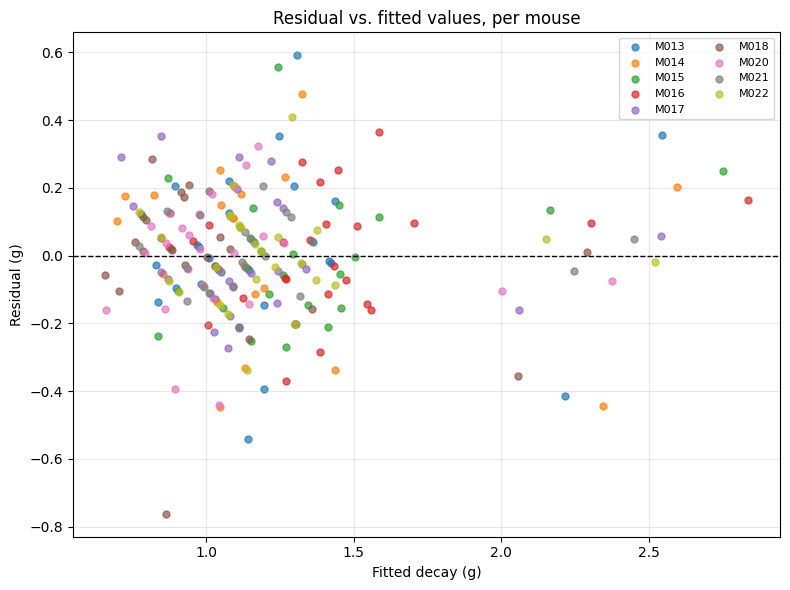

In [ ]:
# ---- residual vs. fitted values, per mouse ----

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
mice = sorted(transitions['subject_id'].unique())
resid = result.resid
fitted = result.fittedvalues

for i, subject_id in enumerate(mice):
    s = transitions[transitions['subject_id'] == subject_id]
    color = colors[i % len(colors)]
    ax.scatter(fitted.loc[s.index], resid.loc[s.index], color=color, label=subject_id, s=25, alpha=0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Fitted decay (g)')
ax.set_ylabel('Residual (g)')
ax.set_title('Residual vs. fitted values, per mouse')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()